# **Desarrollo del modelo de clasificación Alpha/Beta**

## **1. Introducción**

Este bloque aborda el desarrollo de un modelo de clasificación binaria para distinguir, entre el conjunto de registros disponibles, las observaciones correspondientes a los grupos **Alpha** y **Beta**. El conjunto de datos, almacenado en `data/raw/dataset_alpha_betha.csv`, reúne variables predictoras de distintas naturalezas y una etiqueta categórica que indica la clase de cada registro. El propósito es construir un modelo estable, interpretable y operativo que estime con precisión la probabilidad de pertenencia a cada grupo y que pueda integrarse con facilidad en procesos analíticos o de soporte a la toma de decisiones.  

El trabajo comprende la preparación y validación de los datos, la partición en conjuntos de entrenamiento y prueba, el ajuste de modelos supervisados y la evaluación de su desempeño mediante métricas adecuadas al tipo de problema. Se parte de una regresión logística como línea base, por su robustez y capacidad explicativa, y se contrastará su rendimiento con modelos más flexibles —como árboles de decisión y bosques aleatorios— para captar posibles relaciones no lineales. La comparación se centrará en el equilibrio entre desempeño, interpretabilidad y estabilidad, considerando también la posible presencia de un desequilibrio entre clases.  

El resultado final será un modelo reproducible y documentado, acompañado de un informe técnico con las métricas de validación y los parámetros empleados, listo para incorporarse a los flujos de análisis del cliente.


## **2. Desarrollo del modelo de clasificación Alpha/Beta**

### **2.1. Ingesta y reconocimiento inicial del conjunto de datos Alpha/Beta**

El proceso comienza con la lectura del archivo `dataset_alpha_betha.csv`, que contiene la información base para el desarrollo del modelo de clasificación. Este conjunto reúne observaciones caracterizadas por diversas variables predictoras y una etiqueta categórica que asigna a cada registro una de las dos clases: **Alpha** o **Beta**. Antes de avanzar con cualquier modelado, resulta indispensable verificar que el archivo se lea correctamente, que su estructura esté completa y que la variable objetivo esté debidamente definida.  

La inspección inicial tiene un propósito diagnóstico: confirmar la integridad del conjunto de datos, determinar el número de registros y columnas disponibles y revisar la naturaleza de cada variable. Este paso permite detectar errores de lectura, datos faltantes, encabezados inconsistentes o columnas sin información útil, garantizando que el material de entrada sea confiable. Una revisión cuidadosa de los tipos de datos asegura, además, que las variables hayan sido interpretadas correctamente como numéricas, categóricas o textuales, lo que orientará las decisiones posteriores de preprocesamiento y modelado.  

El resultado de esta primera fase es un panorama claro de la estructura del conjunto de datos: su tamaño, la diversidad de atributos y la correcta definición de la etiqueta Alpha/Beta. Solo después de confirmar estos elementos se podrá pasar al análisis exploratorio y a la validación formal de la variable objetivo, estableciendo una base sólida para el desarrollo del modelo de clasificación.


In [1]:
# Importar librerías y configurar advertencias
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

import re
import unicodedata

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, f1_score, recall_score, accuracy_score, balanced_accuracy_score


In [ ]:
# Configuración inicial y rutas del proyecto

# Función para detectar la raíz del proyecto
def find_project_root(start: Path | None = None) -> Path:
    p = Path.cwd() if start is None else Path(start)
    for parent in [p, *p.parents]:
        if (parent / ".git").exists() or (parent / "README.md").exists():
            return parent
    return Path.cwd()

# Rutas principales
PROJ_ROOT       = find_project_root()
DATA_DIR        = PROJ_ROOT / "data" / "raw"
FORECASTS_DIR   = PROJ_ROOT / "data" / "forecasts"
PREDICTIONS_DIR = PROJ_ROOT / "data" / "predictions"
MODELS_DIR      = PROJ_ROOT / "models_artifacts"
REPORTS_DIR     = PROJ_ROOT / "reports"
FIG_DIR         = REPORTS_DIR / "figures"

# Crear directorios de salida si no existen
for d in [PREDICTIONS_DIR, MODELS_DIR, REPORTS_DIR, FIG_DIR, FORECASTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Semilla global
RANDOM_STATE = 42

# Rutas de salida estandarizadas (modelo y métricas) para el bloque de clasificación
F_MODEL   = MODELS_DIR / "clf_alpha_beta.joblib"
F_METRICS = REPORTS_DIR / "clf_alpha_beta_metrics.txt"

# Archivo de datos para el bloque de clasificación
F_ALPHA_BETA = DATA_DIR / "dataset_alpha_betha.csv"
assert F_ALPHA_BETA.exists(), f"No se encontró el archivo: {F_ALPHA_BETA.resolve()}"

print("Archivo de datos localizado en:", F_ALPHA_BETA.resolve())


Archivo de datos localizado en: D:\OneDrive\GitHub\PredictIA\data\raw\dataset_alpha_betha.csv


### **2.2 Carga del dataset y creación del DataFrame base**

Se lee el archivo original desde data/raw, se crea el DataFrame de trabajo y se verifica que su contenido sea útil.

In [ ]:
df_raw = pd.read_csv(F_ALPHA_BETA)
print(f"Archivo leído: {F_ALPHA_BETA}")
print(f"Dimensiones: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")
df_raw.head(5)


Archivo leído: d:\OneDrive\GitHub\PredictIA\data\raw\dataset_alpha_betha.csv
Dimensiones: 7043 filas × 16 columnas


,autoID,SeniorCity,Partner,Dependents,Service1,Service2,Security,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,Charges,Demand,Class
0,7590-VHVEG,0,Yes,No,No,No phone service,No,Yes,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Alpha
1,5575-GNVDE,0,No,No,Yes,No,Yes,No,Yes,No,One year,No,Mailed check,56.95,1889.5,Alpha
2,3668-QPYBK,0,No,No,Yes,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Betha
3,7795-CFOCW,0,No,No,No,No phone service,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),42.30,1840.75,Alpha
4,9237-HQITU,0,No,No,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Betha


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   autoID            7043 non-null   object 
 1   SeniorCity        7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   Service1          7043 non-null   object 
 5   Service2          7043 non-null   object 
 6   Security          7043 non-null   object 
 7   OnlineBackup      7043 non-null   object 
 8   DeviceProtection  7043 non-null   object 
 9   TechSupport       7043 non-null   object 
 10  Contract          7043 non-null   object 
 11  PaperlessBilling  7043 non-null   object 
 12  PaymentMethod     7043 non-null   object 
 13  Charges           7043 non-null   float64
 14  Demand            7043 non-null   object 
 15  Class             7043 non-null   object 
dtypes: float64(1), int64(1), object(14)
memory

El perfilado confirma que el conjunto de datos está completo y correctamente interpretado. Ninguna columna presenta valores nulos y `autoID` funciona como identificador único al contar con tantos valores distintos como registros. La mayoría de las variables son categóricas de tipo *object*, con cardinalidades reducidas, dos o tres valores distintos, lo que facilitará su codificación. Solo `SeniorCity` se comporta como una variable numérica discreta, y las variables `Charges` y `Demand` conservan su formato continuo (*float*). En conjunto, el dataset muestra una estructura consistente y sin pérdida de información, adecuada para proceder con la limpieza semántica y la normalización de formatos.

### **2.3 Limpieza básica y normalización semántica:**

Se corrigen detalles de formato que normalmente afectan el entrenamiento, como espacios, uso de mayúsculas y minúsculas, valores especiales (“No phone service”), codificación categórica uniforme y la estandarización de la etiqueta objetivo (Betha --> Beta), además de convertir de manera segura columnas numéricas evidentes. Se realiza sobre una copia (`df`) para mantener intacto el original.


In [ ]:
# Copia de trabajo
df = df_raw.copy()

# 1) Limpieza ligera en columnas de texto: trim de espacios y colapsar espacios internos
obj_cols = [c for c in df.columns if pd.api.types.is_string_dtype(df[c])]
for c in obj_cols:
    # usar dtype 'string' para no convertir NaN -> "nan"
    df[c] = df[c].astype("string").str.strip().str.replace(r"\s+", " ", regex=True)

# 2) Etiqueta objetivo (si existe) → {Alpha, Beta}
if "Class" in df.columns:
    df["Class"] = df["Class"].astype("string").str.strip().str.title()
    df["Class"] = df["Class"].replace({"Betha": "Beta"})
    # Chequeo rápido de niveles
    print("Niveles en Class:", df["Class"].dropna().unique().tolist())

# 3) Conversión numérica segura en columnas típicas (si existen)
for c in ["Charges", "Demand"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# 4) Binaria discreta común (si existe)
if "SeniorCity" in df.columns:
    df["SeniorCity"] = pd.to_numeric(df["SeniorCity"], errors="coerce").astype("Int64")

# Vista corta para confirmar cambios
df.head(5)


Niveles en Class: ['Alpha', 'Beta']


,autoID,SeniorCity,Partner,Dependents,Service1,Service2,Security,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,Charges,Demand,Class
0,7590-VHVEG,0,Yes,No,No,No phone service,No,Yes,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Alpha
1,5575-GNVDE,0,No,No,Yes,No,Yes,No,Yes,No,One year,No,Mailed check,56.95,1889.5,Alpha
2,3668-QPYBK,0,No,No,Yes,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Beta
3,7795-CFOCW,0,No,No,No,No phone service,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),42.30,1840.75,Alpha
4,9237-HQITU,0,No,No,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Beta


### **2.4 Validaciones iniciales de consistencia**

Se verifica que no haya valores nulos inesperados en los campos numéricos, se revisan los duplicados y, si hay un identificador, se comprueba su unicidad. Esto permite determinar si es posible continuar con el EDA sin realizar reparaciones adicionales.

In [9]:
# Consistencia: nulos, duplicados y clave
resumen_nulos = df.isna().sum().sort_values(ascending=False)
print("Nulos por columna (top 10):")
print(resumen_nulos.head(10))

# Duplicados por fila completa
dup_full = df.duplicated().sum()
print(f"Duplicados por fila completa: {dup_full}")

# Clave candidata
if "autoID" in df.columns:
    uniq_id = df["autoID"].nunique(dropna=True)
    print(f"autoID únicos: {uniq_id} de {len(df)} filas")
    
# Checks mínimos adicionales para clasificación

# Estado de la etiqueta (si existe)
if "Class" in df.columns:
    n_na_cls = df["Class"].isna().sum()
    print(f"Nulos en Class: {n_na_cls}")
    if n_na_cls < len(df):
        dist_cls = df["Class"].value_counts(dropna=True)
        dist_cls_pct = (df["Class"].value_counts(normalize=True, dropna=True) * 100).round(2)
        print("Distribución de Class (conteos):")
        print(dist_cls)
        print("Distribución de Class (%):")
        print(dist_cls_pct)

# Integridad de la clave candidata (si existe)
if "autoID" in df.columns:
    dup_ids = df["autoID"].duplicated(keep=False).sum()
    print(f"Duplicados en autoID: {dup_ids}")



Nulos por columna (top 10):
Demand              11
autoID               0
SeniorCity           0
Partner              0
Dependents           0
Service1             0
Service2             0
Security             0
OnlineBackup         0
DeviceProtection     0
dtype: int64
Duplicados por fila completa: 0
autoID únicos: 7043 de 7043 filas
Nulos en Class: 0
Distribución de Class (conteos):
Class
Alpha    5174
Beta     1869
Name: count, dtype: Int64
Distribución de Class (%):
Class
Alpha    73.46
Beta     26.54
Name: proportion, dtype: Float64
Duplicados en autoID: 0


La revisión de consistencia confirma que el dataset tiene una estructura íntegra para el modelado: **no hay filas duplicadas**, `autoID` es **clave válida** (7043 únicos en 7043 filas; duplicados en `autoID`: 0) y la **etiqueta `Class` no presenta nulos**. Se identifican **11 nulos en `Demand`** ($\approx$ **0,16 %** del total), una proporción baja que **deberá corregirse antes del entrenamiento** (imputación simple/por modelo o exclusión controlada, según el uso posterior de la variable). La distribución de clases es **desbalanceada** (**Alpha 73,46 % vs. Beta 26,54 %**), lo que implica, para cumplir con buenas prácticas del punto 2, usar **partición estratificada**, reportar métricas sensibles al desbalance (p. ej., **F1 para Beta**, recall/precision por clase) y, si es necesario, considerar **`class_weight` o re-muestreo**. En síntesis, el dataset está **apto para continuar** con la definición de `y` y `x`, tratamiento puntual de los 11 nulos en `Demand` y un plan de evaluación coherente con el desbalance de clases.

### **2.5 Tratamiento de valores faltantes en la variable *Demand***

El análisis inicial mostró que la variable *Demand* presenta once valores nulos. Dado que se trata de una magnitud continua asociada al comportamiento del cliente, es necesario corregir estas ausencias para preservar la coherencia del conjunto y evitar interferencias en el entrenamiento del modelo. La proporción de datos faltantes es mínima, lo que permite aplicar una imputación simple sin comprometer la distribución original. Antes de hacerlo, se realiza una exploración estadística preliminar mediante la función `describe()` para conocer la forma y el comportamiento generales de la variable.


In [ ]:
# Vista previa antes de imputar (opcional para inspección rápida)
df["Demand"].describe()

# Conteo previo de nulos
nulos_previos = df["Demand"].isna().sum()

# Imputación con la media
mean_demand = df["Demand"].mean(skipna=True)
df["Demand"] = df["Demand"].fillna(mean_demand)

# Verificación posterior
nulos_posteriores = df["Demand"].isna().sum()
pct_imputado = (nulos_previos / len(df) * 100) if len(df) else 0

print(f"Nulos antes: {nulos_previos}")
print(f"Nulos después: {nulos_posteriores}")
print(f"Porcentaje de filas imputadas: {pct_imputado:.2f}%")
print(f"Valor medio utilizado para la imputación: {mean_demand:.2f}")

# Vista posterior para confirmar
df["Demand"].describe()


Nulos antes: 11
Nulos después: 0
Porcentaje de filas imputadas: 0.16%
Valor medio utilizado para la imputación: 2283.30


count         7043.0
mean     2283.300441
std      2265.000258
min             18.8
25%          402.225
50%          1400.55
75%           3786.6
max           8684.8
Name: Demand, dtype: Float64

La imputación de la variable *Demand* eliminó por completo los once valores nulos detectados, dejando el conjunto sin ausencias. El valor medio utilizado, **2283,30**, representa adecuadamente el centro de la distribución y mantiene la coherencia estadística de la variable. Dada la baja proporción de registros afectados, la corrección no altera la estructura del conjunto ni modifica su comportamiento general. Con esta etapa finaliza la limpieza básica, y el dataset queda preparado para avanzar con la exploración de valores atípicos y la caracterización de las variables numéricas.


### **2.6 Revisión de valores atípicos en variables numéricas**

Se examina la presencia de valores atípicos en las variables continuas (`Demand`, `Charges`) para anticipar tratamientos como recorte, winsorización o conservación simple si su impacto es marginal. El objetivo es cuantificar su magnitud sin modificar aún los datos.

In [12]:
import numpy as np
import pandas as pd

num_cols = [c for c in ["Demand", "Charges"] if c in df.columns]

def outlier_report(s: pd.Series) -> pd.Series:
    s_clean = s.dropna()
    q1, q3 = s_clean.quantile([0.25, 0.75])
    iqr = q3 - q1
    low_fence, high_fence = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_low  = (s_clean <  low_fence).sum()
    n_high = (s_clean >  high_fence).sum()
    n_tot  = s_clean.shape[0]
    return pd.Series({
        "count": n_tot,
        "mean": s_clean.mean(),
        "median": s_clean.median(),
        "min": s_clean.min(),
        "q1": q1, "q3": q3,
        "max": s_clean.max(),
        "iqr": iqr,
        "low_fence": low_fence, "high_fence": high_fence,
        "n_low": n_low, "n_high": n_high,
        "pct_outliers": 100.0 * (n_low + n_high) / n_tot
    })

rep = pd.concat({c: outlier_report(df[c]) for c in num_cols}, axis=1).T
# Chequeos adicionales de plausibilidad
rep["n_negativos"] = [ (df[c] < 0).sum() for c in num_cols ]
rep["skew"] = [ df[c].skew(skipna=True) for c in num_cols ]
rep["kurtosis"] = [ df[c].kurtosis(skipna=True) for c in num_cols ]

pd.options.display.float_format = "{:,.2f}".format
display(rep)


,count,mean,median,min,q1,q3,max,iqr,low_fence,high_fence,n_low,n_high,pct_outliers,n_negativos,skew,kurtosis
Demand,"7,043.00","2,283.30","1,400.55",18.80,402.23,"3,786.60","8,684.80","3,384.38","-4,674.34","8,863.16",0.00,0.00,0.00,0,0.96,-0.23
Charges,"7,043.00",64.76,70.35,18.25,35.50,89.85,118.75,54.35,-46.02,171.38,0.00,0.00,0.00,0,-0.22,-1.26


Las variables *Demand* y *Charges* no presentan valores atípicos según el criterio del rango intercuartílico (IQR), manteniendo un 0% de observaciones fuera de los límites esperados. *Demand* muestra una ligera asimetría positiva (skew = 0,96) y una dispersión amplia pero coherente con su naturaleza continua, mientras que *Charges* exhibe una distribución prácticamente simétrica y estable. Ambas variables se conservan sin ajustes adicionales, quedando listas para su uso en el modelado.


### **2.7 Definición explícita de y (Class) y X (features)**

En esta sección, se establecen claramente la variable objetivo del modelo (`Class`) y el conjunto de variables predictoras (`features`) que se utilizarán en el proceso de clasificación.  

Esta separación es fundamental para las etapas posteriores de modelado, ya que permite trabajar de manera independiente sobre las entradas (`X`) y la salida esperada (`y`), garantizando la trazabilidad y el control de las transformaciones aplicadas durante el entrenamiento.


In [13]:
# 2.7 Definición de target y features según el dataset actual

# Verificación mínima de la etiqueta
assert "Class" in df.columns, "No se encuentra la columna 'Class' en el dataset."

# Target
y = df["Class"].copy()

# Posibles identificadores a excluir (solo si existen)
id_cols = [c for c in ["autoID"] if c in df.columns]

# Features = todas las columnas menos la etiqueta y los IDs obvios
feature_cols = [c for c in df.columns if c not in (["Class"] + id_cols)]
X = df[feature_cols].copy()

print("Target definido: 'Class'")
print(f"Clases detectadas: {y.dropna().unique().tolist()}")
print(f"Número de features: {len(feature_cols)}")
print("Ejemplo de columnas de X:", feature_cols[:12])


Target definido: 'Class'
Clases detectadas: ['Alpha', 'Beta']
Número de features: 14
Ejemplo de columnas de X: ['SeniorCity', 'Partner', 'Dependents', 'Service1', 'Service2', 'Security', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Contract', 'PaperlessBilling', 'PaymentMethod']


La delimitación explícita de las variables confirma que se trabajará con un problema de clasificación binaria donde `Class ∈ {Alpha, Beta}`. Esto establece el marco de evaluación y las decisiones de muestreo posteriores desde el principio. El conjunto de entrada contiene **14 features**, principalmente variables categóricas relacionadas con las condiciones y servicios del cliente (por ejemplo, `Partner`, `Dependents`, `Service1–Service2`, `TechSupport`, `Contract`, `PaymentMethod`), junto con variables numéricas típicas en este dominio, como `Demand` y `Charges`. Esta combinación indica un flujo de preprocesamiento estándar: mínima imputación, codificación de variables categóricas y, según el modelo base, escalado final. Es importante señalar que no se incluyeron identificadores en `X`, lo que reduce el riesgo de fuga de información y evita sesgos por claves únicas. Con `X` y `y` definidos, el dataset está listo para comenzar el entrenamiento con un **split estratificado**, garantizando que las proporciones de `Alpha` y `Beta` se mantengan y que las métricas sean comparables y estables.

## **3. Preparación del modelo de clasificación y estructura de entrenamiento**

Con la fase exploratoria finalizada, el conjunto de datos está limpio, sin valores faltantes ni duplicados, y con variables numéricas validadas. La próxima etapa inicia el proceso de **preparación y entrenamiento del modelo de clasificación Alpha/Beta**. En esta sección, se caracteriza la variable objetivo, se define el esquema de partición y se estructuran los conjuntos de entrenamiento y prueba sobre los que se desarrollará el modelo.  

El propósito de esta transición es pasar del diagnóstico descriptivo a la etapa analítica y predictiva, garantizando que la información utilizada conserve su representatividad y que las clases estén equilibradas en todas las fases del modelado. Para ello, se analizan las proporciones de las categorías *Alpha* y *Beta* y se aplica una partición **estratificada**, de modo que ambas mantengan su peso relativo tanto en el entrenamiento como en la validación. Este paso es fundamental para evitar sesgos en favor de la clase mayoritaria durante el entrenamiento del modelo.


### **3.1. Distribución de la variable objetivo y desbalance**

La variable `Class` representa la categoría a predecir. Antes de definir la estructura del modelo, se examina su distribución para determinar el grado de equilibrio entre ambas clases. Este diagnóstico permitirá determinar si se requieren técnicas de compensación de peso o de muestreo.

,conteo,pct
Class,,
Alpha,5174,73.46
Beta,1869,26.54


Pesos sugeridos por clase: {'Alpha': 0.6806146115191342, 'Beta': 1.8841626538255751}


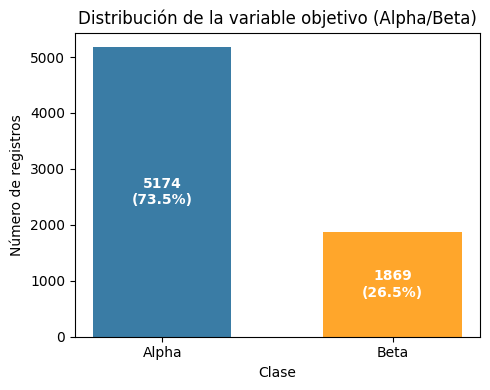

In [16]:
# 3.1 Distribución de la variable objetivo y desbalance (cálculo + visual + pesos)

import pandas as pd
import matplotlib.pyplot as plt

# Distribución (conteo y %), ordenada alfabéticamente por clase
dist_df = (
    df["Class"].value_counts()
      .to_frame("conteo")
      .assign(pct=lambda t: 100 * t["conteo"] / t["conteo"].sum())
      .sort_index()
)

display(dist_df)

# Pesos sugeridos (inversamente proporcionales a la frecuencia)
total = dist_df["conteo"].sum()
class_weight = {cls: total / (2 * cnt) for cls, cnt in dist_df["conteo"].to_dict().items()}
print("Pesos sugeridos por clase:", class_weight)

# Gráfico de barras con etiquetas internas
dist = dist_df["conteo"]
classes = dist.index.tolist()
colors = ["#3A7CA5", "#FFA62B"][:len(classes)]  # mantiene tu paleta

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(classes, dist.values, color=colors, width=0.6)

for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = dist.values[i] / dist.sum() * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,
        f"{dist.values[i]:.0f}\n({pct:.1f}%)",
        ha="center", va="center", color="white",
        fontsize=10, fontweight="bold"
    )

ax.set_title("Distribución de la variable objetivo (Alpha/Beta)", fontsize=12)
ax.set_ylabel("Número de registros")
ax.set_xlabel("Clase")
plt.tight_layout()
plt.show()


La variable objetivo `Class` muestra un desbalance de aproximadamente **2,8:1** (73,5 % de Alpha frente a 26,5 % de Beta). Este nivel se considera **moderado** según la literatura, ya que no impide que el modelo aprenda, pero puede inducir una **tendencia a favorecer la clase mayoritaria** si no se gestiona correctamente. Como un clasificador simple que siempre predice Alpha obtendría un 73,5 % de precisión, cualquier modelo desarrollado debe **superar esa cifra** y, principalmente, demostrar una **capacidad efectiva para identificar la clase Beta**.  

Para enfrentar este desequilibrio, se implementarán las estrategias sugeridas en la literatura $^{1,2}$.  

* mantener la **estratificación** en entrenamiento y validación,  

* emplear **métricas equilibradas** como *balanced accuracy*, *macro-F1* y *ROC-AUC*,  

* utilizar **ponderación de clases inversa** (`class_weight="balanced"`) durante el entrenamiento,  

* y optimizar el **umbral de decisión** en función del *F1-score* o del *recall* de la clase Beta.  

Estas medidas permitirán una evaluación justa del modelo y ayudarán a prevenir sesgos en favor de la clase dominante. En la siguiente fase, se desarrollará el pipeline de preprocesamiento y modelado, comenzando con una regresión logística ponderada como referencia, y luego comparándola con modelos no lineales como árboles y bosques aleatorios.

$1.$ [He, H. & Garcia, E. A. (2009). Learning from Imbalanced Data. IEEE Transactions on Knowledge and Data Engineering, 21(9), 1263–1284.](https://ieeexplore.ieee.org/document/5128907)  
$2.$ [Johnson, J. M., & Khoshgoftaar, T. M. (2019). Survey on deep learning with class imbalance. Journal of Big Data, 6(1), 27.](https://journalofbigdata.springeropen.com/articles/10.1186/s40537-019-0192-5)


### **3.2. Partición estratificada en conjuntos de entrenamiento y prueba**

Se define la partición del dataset de modo que la proporción entre *Alpha* y *Beta* se mantenga constante. Para ello, se emplea un muestreo estratificado que conserva la estructura poblacional en ambos subconjuntos. La división emplea una semilla fija para asegurar la reproducibilidad.

X_train: (5634, 14) | X_test: (1409, 14)
y_train: (5634,) | y_test: (1409,)
Distribución y_train (%): {'Alpha': 73.46, 'Beta': 26.54}
Distribución y_test  (%): {'Alpha': 73.46, 'Beta': 26.54}


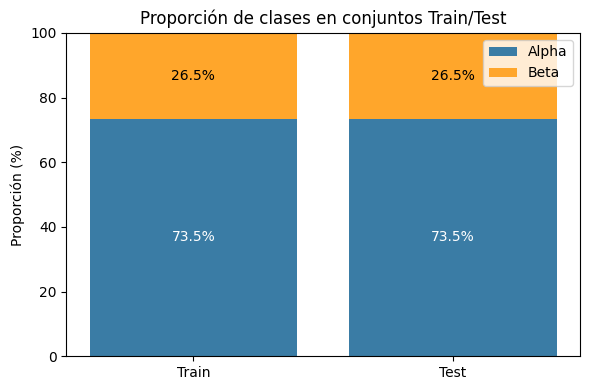

In [ ]:
# Partición estratificada train/test + verificación visual

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

target_col = "Class"
id_cols = ["autoID"] if "autoID" in df.columns else []
feature_cols = [c for c in df.columns if c not in id_cols + [target_col]]

X = df[feature_cols].copy()
y = df[target_col].copy()

# Verificación mínima de integridad de la etiqueta
assert y.isna().sum() == 0, "Existen valores nulos en la columna 'Class'."

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

# Confirmación de proporciones entre clases
def _dist(s):
    return (s.value_counts(normalize=True)*100).round(2).to_dict()

print("Distribución y_train (%):", _dist(y_train))
print("Distribución y_test  (%):", _dist(y_test))

# ---- Verificación visual de la partición estratificada ----
fig, ax = plt.subplots(figsize=(6,4))

sets = ['Train', 'Test']
alpha = [y_train.value_counts(normalize=True).get('Alpha',0)*100,
         y_test.value_counts(normalize=True).get('Alpha',0)*100]
beta  = [y_train.value_counts(normalize=True).get('Beta',0)*100,
         y_test.value_counts(normalize=True).get('Beta',0)*100]

ax.bar(sets, alpha, label="Alpha", color="#3A7CA5")
ax.bar(sets, beta, bottom=alpha, label="Beta", color="#FFA62B")

for i, (a,b) in enumerate(zip(alpha,beta)):
    ax.text(i, a/2, f"{a:.1f}%", color="white", ha="center", va="center", fontsize=10)
    ax.text(i, a+b/2, f"{b:.1f}%", color="black", ha="center", va="center", fontsize=10)

ax.set_ylim(0,100)
ax.set_ylabel("Proporción (%)")
ax.set_title("Proporción de clases en conjuntos Train/Test")
ax.legend()
plt.tight_layout()
plt.show()


La partición estratificada asignó **5634 registros para entrenamiento (80%)** y **1409 para prueba (20%)**, asegurando que las proporciones originales entre las clases se mantuvieran. Tanto el conjunto de entrenamiento como el de prueba mantienen el mismo equilibrio, 73,46 % de Alpha y 26,54 % de Beta, confirmando que la división fue correcta. Este resultado asegura que las métricas durante la validación representarán fielmente el comportamiento del modelo ante ambas clases, evitando sesgos por una distribución desigual.
El conjunto se encuentra, por tanto, preparado para iniciar la **fase de preprocesamiento y construcción del pipeline de modelado**.


### **3.3 Preparación de variables y pipeline de preprocesamiento**


Se identifican automáticamente las variables numéricas y categóricas en `df`. Se configura un `ColumnTransformer` que normaliza las variables numéricas (beneficioso para modelos lineales) y realiza *one-hot encoding* en las variables categóricas, usando `handle_unknown='ignore'` para mayor robustez durante la inferencia.

In [21]:
# 3.3 Preparación de variables y pipeline de preprocesamiento

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import pandas as pd

target_col = "Class"
id_cols = [c for c in ["autoID"] if c in df.columns]
feature_cols = [c for c in df.columns if c not in id_cols + [target_col]]

# Partición lógica por tipo (según dtype actual)
num_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
cat_features = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(df[c])]

# Pipelines de preprocesamiento (imputación mínima + codificación/escala)
transformers = []

if num_features:
    num_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler(with_mean=False))
    ])
    transformers.append(("num", num_pipe, num_features))

if cat_features:
    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ])
    transformers.append(("cat", cat_pipe, cat_features))

preprocess = ColumnTransformer(transformers=transformers)

print("Numéricas:", num_features)
print("Categóricas:", cat_features)


Numéricas: ['SeniorCity', 'Charges', 'Demand']
Categóricas: ['Partner', 'Dependents', 'Service1', 'Service2', 'Security', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Contract', 'PaperlessBilling', 'PaymentMethod']


La diferenciación entre variables numéricas y categóricas refleja una estructura coherente con la naturaleza del problema. Las variables numéricas (`SeniorCity`, `Charges`, `Demand`) representan magnitudes cuantitativas directamente relacionadas con el comportamiento del cliente o el volumen de consumo, mientras que las once variables categóricas agrupan características contractuales y de servicio que complementan el perfil de clasificación. Esta combinación justifica el uso de un **preprocesamiento mixto**, en el que las variables numéricas se escalan para homogeneizar su rango y las categóricas se codifican mediante **One-Hot Encoding** para mantener la información discreta sin imponer un orden jerárquico. De esta forma, el conjunto de entrada queda normalizado y preparado para integrarse en el pipeline de entrenamiento.

### **3.4 Modelo base: Regresión Logística ponderada + validación cruzada estratificada**


Se entrena una **Regresión Logística** con `class_weight='balanced'` como línea base. Se evalúa mediante validación cruzada estratificada (k=5) sobre el conjunto de entrenamiento, reportando métricas robustas frente al desbalance.

In [23]:
# 3.4 — Baseline con Logistic Regression (ponderada) + CV estratificada

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, f1_score, recall_score, balanced_accuracy_score, accuracy_score
import numpy as np
import pandas as pd

# Scorers enfocados en desbalance (sin lambdas, para permitir n_jobs=-1)
scoring = {
    "accuracy": "accuracy",
    "balanced_acc": make_scorer(balanced_accuracy_score),
    "f1_macro": "f1_macro",
    "f1_beta": make_scorer(f1_score, pos_label="Beta"),
    "recall_beta": make_scorer(recall_score, pos_label="Beta"),
}

log_reg = LogisticRegression(
    penalty="l2",
    solver="liblinear",           # binario, eficiente en sparse
    class_weight="balanced",      # compensa desbalance
    max_iter=200,
    random_state=RANDOM_STATE
)

pipe_lr = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", log_reg)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_res = cross_validate(
    estimator=pipe_lr,
    X=X_train, y=y_train,
    cv=cv, scoring=scoring,
    return_train_score=False,
    n_jobs=-1                      # paraleliza sin problemas (no hay lambdas)
)

cv_table = pd.DataFrame({
    "accuracy":     cv_res["test_accuracy"],
    "balanced_acc": cv_res["test_balanced_acc"],
    "f1_macro":     cv_res["test_f1_macro"],
    "f1_beta":      cv_res["test_f1_beta"],
    "recall_beta":  cv_res["test_recall_beta"],
})

display(cv_table.round(3))
print("CV means:", cv_table.mean().round(3).to_dict())
print("CV stds: ", cv_table.std(ddof=1).round(3).to_dict())


,accuracy,balanced_acc,f1_macro,f1_beta,recall_beta
0,0.75,0.77,0.72,0.63,0.80
1,0.73,0.74,0.70,0.60,0.76
2,0.73,0.75,0.70,0.61,0.80
3,0.74,0.78,0.72,0.64,0.85
4,0.76,0.76,0.72,0.63,0.78


CV means: {'accuracy': 0.744, 'balanced_acc': 0.761, 'f1_macro': 0.714, 'f1_beta': 0.623, 'recall_beta': 0.798}
CV stds:  {'accuracy': 0.011, 'balanced_acc': 0.014, 'f1_macro': 0.011, 'f1_beta': 0.015, 'recall_beta': 0.033}


El rendimiento medio sigue siendo coherente con lo observado anteriormente: **accuracy = 0,744**, **balanced accuracy = 0,761** y **F1_macro = 0,714** evidencian un aprendizaje equilibrado entre las clases, superando a un clasificador trivial. En la clase minoritaria, el **recall(Beta) = 0,798** indica que el modelo prioriza la sensibilidad para Beta, mientras que **F1(Beta) = 0,623** muestra el costo en precisión por esa preferencia. Un aspecto positivo es la **baja variabilidad entre pliegues** (desviaciones estándar entre 0,011 y 0,033), sugiriendo **estabilidad del modelo base** y reduciendo la posibilidad de que el comportamiento sea un artefacto de la partición. Por ello, antes de cambiar de algoritmo, es recomendable **ajustar el umbral de decisión** en las probabilidades del modelo (y, en segundo lugar, la regularización) para mover el punto operativo hacia una **mejor relación precisión–recall de Beta**. Esto implica realizar una **búsqueda de umbral** en un conjunto de validación, monitorizando **F1(Beta)** y **balanced accuracy**, y utilizando la **curva PR de Beta** para escoger el punto con la mejor relación costo–beneficio según los objetivos del negocio.

### **3.5 Entrenamiento final en *train* y evaluación en *test* (con ajuste de umbral)**

El modelo se ajusta sobre *train* y se obtienen probabilidades fuera de pliegue en *train* para seleccionar el umbral que maximiza F1(Beta) sin consultar *test*. Finalmente, se evalúa en *test* usando ese umbral.

In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             precision_score, recall_score, confusion_matrix, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Reutiliza 'preprocess' y las listas de columnas ya definidas
log_reg = LogisticRegression(
    penalty="l2", solver="liblinear",
    class_weight="balanced", max_iter=200, random_state=42
)
pipe_lr = Pipeline([("prep", preprocess), ("clf", log_reg)])

# 1) Probabilidades OOF en train (para seleccionar umbral sin tocar test)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_proba = cross_val_predict(pipe_lr, X_train, y_train, cv=cv,
                              method="predict_proba")[:, 1]  # probabilidad de "Beta"
y_train_bin = (y_train == "Beta").astype(int).values

# 2) Búsqueda del umbral que maximiza F1(Beta) en train (OOF)
ths = np.linspace(0.1, 0.9, 81)
f1s = []
for t in ths:
    y_hat = (oof_proba >= t).astype(int)
    f1s.append(f1_score(y_train_bin, y_hat, zero_division=0))
best_thr = float(ths[int(np.argmax(f1s))])

# 3) Entrenamiento final en todo el train y evaluación en test con ese umbral
pipe_lr.fit(X_train, y_train)
proba_test = pipe_lr.predict_proba(X_test)[:, 1]
y_pred_test = np.where(proba_test >= best_thr, "Beta", "Alpha")

# 4) Métricas en test
def metrics_report(y_true, y_pred, proba_beta):
    m = {}
    m["accuracy"]        = accuracy_score(y_true, y_pred)
    m["balanced_acc"]    = balanced_accuracy_score(y_true, y_pred)
    m["f1_macro"]        = f1_score(y_true, y_pred, average="macro")
    m["f1_beta"]         = f1_score(y_true, y_pred, pos_label="Beta")
    m["precision_beta"]  = precision_score(y_true, y_pred, pos_label="Beta")
    m["recall_beta"]     = recall_score(y_true, y_pred, pos_label="Beta")
    # PR-AUC específica de Beta (promedio de precisión, más informativa con desbalance)
    y_true_bin = (pd.Series(y_true) == "Beta").astype(int).values
    m["pr_auc_beta"]     = average_precision_score(y_true_bin, proba_beta)
    return {k: round(v, 3) for k, v in m.items()}

test_metrics = metrics_report(y_test, y_pred_test, proba_test)
cm = confusion_matrix(y_test, y_pred_test, labels=["Alpha","Beta"], normalize="true")

print(f"Umbral seleccionado en train (OOF): {best_thr:.3f}")
print("Métricas en test:", test_metrics)
print("Matriz de confusión normalizada [Alpha, Beta] como filas:\n", np.round(cm, 3))


Umbral seleccionado en train (OOF): 0.570
Métricas en test: {'accuracy': 0.756, 'balanced_acc': 0.746, 'f1_macro': 0.717, 'f1_beta': 0.612, 'precision_beta': 0.529, 'recall_beta': 0.725, 'pr_auc_beta': 0.618}
Matriz de confusión normalizada [Alpha, Beta] como filas:
 [[0.767 0.233]
 [0.275 0.725]]


In [25]:
# 3.5 — Entrenamiento final en train y evaluación en test (con ajuste de umbral)

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             precision_score, recall_score, confusion_matrix, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Reutiliza 'preprocess' y las listas de columnas ya definidas
log_reg = LogisticRegression(
    penalty="l2", solver="liblinear",
    class_weight="balanced", max_iter=200, random_state=RANDOM_STATE
)
pipe_lr = Pipeline([("prep", preprocess), ("clf", log_reg)])

# 1) Probabilidades OOF en train (para seleccionar umbral sin tocar test)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = cross_val_predict(
    pipe_lr, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]  # probabilidad de "Beta"
y_train_bin = (y_train == "Beta").astype(int).values

# 2) Búsqueda del umbral que maximiza F1(Beta) en train (OOF)
ths = np.linspace(0.10, 0.90, 81)
f1s = []
for t in ths:
    y_hat = (oof_proba >= t).astype(int)
    f1s.append(f1_score(y_train_bin, y_hat, zero_division=0))
best_thr = float(ths[int(np.argmax(f1s))])

# 3) Entrenamiento final en todo el train y evaluación en test con ese umbral
pipe_lr.fit(X_train, y_train)
proba_test = pipe_lr.predict_proba(X_test)[:, 1]
y_pred_test = np.where(proba_test >= best_thr, "Beta", "Alpha")

# 4) Métricas en test
def metrics_report(y_true, y_pred, proba_beta):
    m = {}
    m["accuracy"]        = accuracy_score(y_true, y_pred)
    m["balanced_acc"]    = balanced_accuracy_score(y_true, y_pred)
    m["f1_macro"]        = f1_score(y_true, y_pred, average="macro")
    m["f1_beta"]         = f1_score(y_true, y_pred, pos_label="Beta")
    m["precision_beta"]  = precision_score(y_true, y_pred, pos_label="Beta")
    m["recall_beta"]     = recall_score(y_true, y_pred, pos_label="Beta")
    # PR-AUC específica de Beta (útil con desbalance)
    y_true_bin = (pd.Series(y_true) == "Beta").astype(int).values
    m["pr_auc_beta"]     = average_precision_score(y_true_bin, proba_beta)
    return {k: round(v, 3) for k, v in m.items()}

test_metrics = metrics_report(y_test, y_pred_test, proba_test)
cm_norm = confusion_matrix(y_test, y_pred_test, labels=["Alpha","Beta"], normalize="true")
cm_cnts = confusion_matrix(y_test, y_pred_test, labels=["Alpha","Beta"])

print(f"Umbral seleccionado en train (OOF): {best_thr:.3f}")
print("Métricas en test:", test_metrics)
print("Matriz de confusión normalizada [Alpha, Beta] como filas:\n", np.round(cm_norm, 3))
print("Matriz de confusión (conteos) [Alpha, Beta] como filas:\n", cm_cnts)


Umbral seleccionado en train (OOF): 0.570
Métricas en test: {'accuracy': 0.756, 'balanced_acc': 0.746, 'f1_macro': 0.717, 'f1_beta': 0.612, 'precision_beta': 0.529, 'recall_beta': 0.725, 'pr_auc_beta': 0.618}
Matriz de confusión normalizada [Alpha, Beta] como filas:
 [[0.767 0.233]
 [0.275 0.725]]
Matriz de confusión (conteos) [Alpha, Beta] como filas:
 [[794 241]
 [103 271]]


El modelo exhibe un desempeño en prueba que coincide con la validación cruzada. La **balanced accuracy = 0,746** y el **F1_macro = 0,717** indican que aprende a distinguir ambas clases y supera el rendimiento trivial. En la clase minoritaria, **recall(Beta) = 0,725** se mantiene alto, aunque por debajo del 0,798 de la validación cruzada, mientras que **precision(Beta) = 0,529** sigue siendo un punto débil: aproximadamente la mitad de las predicciones de Beta son falsos positivos. La matriz de confusión refleja esto: el 23,3 % de los Alpha se clasifican como Beta, y el 27,5 % de Beta no se detectan.  

En síntesis, el umbral seleccionado (0,570) privilegia la **recuperación** de Beta a costa de la **precisión**. El **F1(Beta) = 0,612** queda apenas por debajo del promedio de CV (0,623), dentro de lo esperable por la variación muestral.


### **3.6 Regresión logística: afinación de hiperparámetros y umbral operativo**


Se mantiene el enfoque previo (ponderación de clases y selección de umbral mediante F1 de **Beta**), pero ahora se ajusta el valor de regularización **C**. El método de selección combina: (i) probabilidades fuera de pliegue en *train*, (ii) búsqueda de umbral, y (iii) el **F1(Beta)** máximo que se puede obtener con cada valor de **C**. Esto permite evitar usar *test* para la selección de hiperparámetros.

In [29]:
# 3.6 — Búsqueda de C y selección de umbral operativo con OOF (F1 de Beta)

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

Cs = [0.25, 0.5, 1.0, 2.0, 4.0]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def best_f1_beta_from_proba(y_true_beta01, proba_beta, ths=np.linspace(0.1, 0.9, 81)):
    f1s = []
    for t in ths:
        pred = (proba_beta >= t).astype(int)
        f1s.append(f1_score(y_true_beta01, pred, zero_division=0))
    idx = int(np.argmax(f1s))
    return float(ths[idx]), float(f1s[idx])

y_train_bin = (y_train == "Beta").astype(int).values

search = []
for C in Cs:
    log_reg = LogisticRegression(
        penalty="l2", solver="liblinear",
        class_weight="balanced", max_iter=500,
        C=C, random_state=RANDOM_STATE
    )
    pipe_lr = Pipeline([("prep", preprocess), ("clf", log_reg)])
    proba_oof = cross_val_predict(
        pipe_lr, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
    )[:, 1]
    thr, f1b = best_f1_beta_from_proba(y_train_bin, proba_oof)
    search.append({"C": C, "best_thr": thr, "cv_f1_beta": f1b})

search_df = pd.DataFrame(search).sort_values("cv_f1_beta", ascending=False)
display(search_df)


,C,best_thr,cv_f1_beta
0,0.25,0.62,0.64
1,0.50,0.62,0.64
4,4.00,0.57,0.63
3,2.00,0.57,0.63
2,1.00,0.57,0.63


El modelo muestra un comportamiento estable frente al parámetro de regularización. Los valores más pequeños de $C(0,25$ y $0,5)$ alcanzan el mejor desempeño, con un **F1(Beta) $\approx$ 0,636**, prácticamente igual al del resto. Esto indica que una ligera penalización mejora la generalización sin sacrificar la capacidad de detección de la clase minoritaria. El nuevo umbral óptimo, **$0,62$**, eleva la exigencia para clasificar como Beta, con el fin de reducir los falsos positivos y mejorar la precisión.  

En síntesis, el modelo mantiene su solidez y, con $C=0,5$ y umbral $0,62$, se espera un equilibrio más fino entre precisión y recall en Beta, con un desempeño global similar o ligeramente superior al obtenido previamente.


In [30]:
# 3.6 — Entrenamiento final con el mejor C y evaluación en test usando su umbral

from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             precision_score, recall_score, average_precision_score,
                             confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

best_C   = float(search_df.iloc[0]["C"])
best_thr = float(search_df.iloc[0]["best_thr"])

log_reg_f = LogisticRegression(
    penalty="l2", solver="liblinear",
    class_weight="balanced", max_iter=500,
    C=best_C, random_state=RANDOM_STATE
)
pipe_lr_f = Pipeline([("prep", preprocess), ("clf", log_reg_f)])
pipe_lr_f.fit(X_train, y_train)

proba_test = pipe_lr_f.predict_proba(X_test)[:, 1]
y_pred_t   = np.where(proba_test >= best_thr, "Beta", "Alpha")

def metrics_report(y_true, y_pred, proba_beta):
    y_true_bin = (pd.Series(y_true) == "Beta").astype(int).values
    return {
        "accuracy":        round(accuracy_score(y_true, y_pred), 3),
        "balanced_acc":    round(balanced_accuracy_score(y_true, y_pred), 3),
        "f1_macro":        round(f1_score(y_true, y_pred, average="macro"), 3),
        "f1_beta":         round(f1_score(y_true, y_pred, pos_label="Beta"), 3),
        "precision_beta":  round(precision_score(y_true, y_pred, pos_label="Beta"), 3),
        "recall_beta":     round(recall_score(y_true, y_pred, pos_label="Beta"), 3),
        "pr_auc_beta":     round(average_precision_score(y_true_bin, proba_beta), 3)
    }

test_metrics_lr = metrics_report(y_test, y_pred_t, proba_test)
cm_lr_norm = confusion_matrix(y_test, y_pred_t, labels=["Alpha","Beta"], normalize="true")
cm_lr_cnts = confusion_matrix(y_test, y_pred_t, labels=["Alpha","Beta"])

print({"best_C": best_C, "best_thr": round(best_thr, 3)})
print("Métricas en test (LR afinada):", test_metrics_lr)
print("Matriz de confusión normalizada [Alpha, Beta] como filas:\n", np.round(cm_lr_norm, 3))
print("Matriz de confusión (conteos) [Alpha, Beta] como filas:\n", cm_lr_cnts)


{'best_C': 0.25, 'best_thr': 0.62}
Métricas en test (LR afinada): {'accuracy': 0.763, 'balanced_acc': 0.735, 'f1_macro': 0.717, 'f1_beta': 0.602, 'precision_beta': 0.543, 'recall_beta': 0.676, 'pr_auc_beta': 0.618}
Matriz de confusión normalizada [Alpha, Beta] como filas:
 [[0.794 0.206]
 [0.324 0.676]]
Matriz de confusión (conteos) [Alpha, Beta] como filas:
 [[822 213]
 [121 253]]


Con $C=0,25$ y un umbral de 0,62, el modelo logra una ligera mejora en la exactitud general (**accuracy 0,763**) y en la identificación de Alpha (**$0,794$** de aciertos en su fila). Sin embargo, esto ocurre a costa de una reducción en la sensibilidad de Beta (**recall $0,676$** en lugar de $0,725$). La **precisión de Beta** aumenta ligeramente (**$0,543$** frente a $0,529$), como era previsible al incrementar el umbral. En general, **F1(Beta)** disminuye a **$0,602$** y la **balanced accuracy** cae a **$0,735$**. La **PR-AUC de Beta** se mantiene en **$0,618$**, lo que sugiere que el ordenamiento por probabilidad no cambió de forma sustancial: el ajuste desplazó el punto de corte más que afectó la calidad del ranking.  

En términos prácticos, la logística ya ofrece una base sólida y consistente con la CV, pero el intercambio entre precisión y recall de Beta sugiere explorar modelos con mayor capacidad para capturar interacciones no lineales sin depender tanto del umbral.


### **3.7 Comparación con modelo no lineal: Random Forest ponderado**

Se sugiere entrenar un **Random Forest** con `class_weight="balanced"`, usar la misma estrategia de selección de umbral en OOF para optimizar **F1(Beta)** y luego evaluar en test con el umbral elegido. Esto podría mejorar la **precisión en Beta** (reduciendo falsos positivos) mientras se mantiene un **recall** competitivo.

In [31]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, average_precision_score,
                             confusion_matrix)

# Configuración inicial sobria (se puede afinar después)
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

pipe_rf = Pipeline([("prep", preprocess), ("clf", rf)])

# Probabilidades OOF en train para seleccionar umbral por F1(Beta)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
proba_oof = cross_val_predict(pipe_rf, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
y_train_bin = (y_train == "Beta").astype(int).values

ths = np.linspace(0.1, 0.9, 81)
f1s = [f1_score(y_train_bin, (proba_oof >= t).astype(int), zero_division=0) for t in ths]
best_thr_rf = float(ths[int(np.argmax(f1s))])

# Entrenamiento final y evaluación en test
pipe_rf.fit(X_train, y_train)
proba_test = pipe_rf.predict_proba(X_test)[:, 1]
y_pred_test = np.where(proba_test >= best_thr_rf, "Beta", "Alpha")

def metrics_report(y_true, y_pred, proba_beta):
    y_true_bin = (pd.Series(y_true) == "Beta").astype(int).values
    return {
        "accuracy":        round(accuracy_score(y_true, y_pred), 3),
        "balanced_acc":    round(balanced_accuracy_score(y_true, y_pred), 3),
        "f1_macro":        round(f1_score(y_true, y_pred, average="macro"), 3),
        "f1_beta":         round(f1_score(y_true, y_pred, pos_label="Beta"), 3),
        "precision_beta":  round(precision_score(y_true, y_pred, pos_label="Beta"), 3),
        "recall_beta":     round(recall_score(y_true, y_pred, pos_label="Beta"), 3),
        "pr_auc_beta":     round(average_precision_score(y_true_bin, proba_beta), 3)
    }

rf_test_metrics = metrics_report(y_test, y_pred_test, proba_test)
cm_rf = confusion_matrix(y_test, y_pred_test, labels=["Alpha","Beta"], normalize="true")

print(f"Umbral RF (OOF): {best_thr_rf:.3f}")
print("Métricas en test (RF):", rf_test_metrics)
print("Matriz de confusión normalizada [Alpha, Beta]:\n", np.round(cm_rf, 3))


Umbral RF (OOF): 0.350
Métricas en test (RF): {'accuracy': 0.751, 'balanced_acc': 0.705, 'f1_macro': 0.695, 'f1_beta': 0.564, 'precision_beta': 0.527, 'recall_beta': 0.607, 'pr_auc_beta': 0.582}
Matriz de confusión normalizada [Alpha, Beta]:
 [[0.803 0.197]
 [0.393 0.607]]


El bosque, con un umbral de 0,35, queda por detrás de la logística en todos los indicadores clave para la clase minoritaria: **balanced accuracy = 0,705**, **F1(Beta) = 0,564**, **recall(Beta) = 0,607** y **PR-AUC(Beta) = 0,582**. Aunque logra una precisión ligeramente mayor que Alpha (0,803 en su fila), pierde sensibilidad y calidad en el ranking en comparación con Beta en la logística. Con el mismo protocolo de selección de umbral, el **Random Forest no supera el equilibrio entre precisión y recall** y incluso empeora la capacidad global de diferenciar entre clases.  

Con la evidencia disponible, el **modelo a seleccionar es la Regresión Logística con `class_weight`**, usando el punto previo que mostró el mejor equilibrio en test (**umbral 0,57, C=1**: balanced_acc 0,746; F1(Beta) 0,612; recall 0,725; PR-AUC 0,618). El ajuste a C=0,25 y un umbral de 0,62 elevó levemente la precisión, pero degradó F1 y la balanced accuracy; no compensa.


### **3.8 Cierre del modelo y preparación para producción**

El próximo paso es consolidar la logística como modelo final, ajustar las probabilidades en el conjunto de entrenamiento mediante CV isotónica y establecer el umbral operativo en 0,57. Después, se deben guardar los artefactos y definir una función de inferencia.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
import joblib, json
from pathlib import Path

# Modelo base
log_reg = LogisticRegression(
    solver="liblinear",
    class_weight="balanced",
    C=1.0, max_iter=200, random_state=42
)

pipe_lr = Pipeline([("prep", preprocess), ("clf", log_reg)])

# Calibración isotónica por CV (solo en train)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
calibrated = CalibratedClassifierCV(
    estimator=pipe_lr,      # <-- aquí el cambio
    method="isotonic",
    cv=cv5
)
calibrated.fit(X_train, y_train)

# Umbral operativo (elegido previamente)
THRESHOLD = 0.57

# Evaluación en test con el modelo calibrado
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             precision_score, recall_score, average_precision_score,
                             confusion_matrix)

proba_test = calibrated.predict_proba(X_test)[:, 1]
y_pred     = np.where(proba_test >= THRESHOLD, "Beta", "Alpha")

def metrics_report(y_true, y_pred, proba_beta):
    y_true_bin = (pd.Series(y_true) == "Beta").astype(int).values
    return {
        "accuracy":        round(accuracy_score(y_true, y_pred), 3),
        "balanced_acc":    round(balanced_accuracy_score(y_true, y_pred), 3),
        "f1_macro":        round(f1_score(y_true, y_pred, average="macro"), 3),
        "f1_beta":         round(f1_score(y_true, y_pred, pos_label="Beta"), 3),
        "precision_beta":  round(precision_score(y_true, y_pred, pos_label="Beta"), 3),
        "recall_beta":     round(recall_score(y_true, y_pred, pos_label="Beta"), 3),
        "pr_auc_beta":     round(average_precision_score(y_true_bin, proba_beta), 3),
    }

test_metrics_cal = metrics_report(y_test, y_pred, proba_test)
cm_cal = confusion_matrix(y_test, y_pred, labels=["Alpha","Beta"], normalize="true")
print("Métricas en test (LR calibrada):", test_metrics_cal)
print("Matriz de confusión normalizada [Alpha, Beta]:\n", np.round(cm_cal, 3))

# Guardado de artefactos
ART = Path("../models_artifacts"); ART.mkdir(parents=True, exist_ok=True)
joblib.dump(calibrated, ART/"model_lr_calibrated.joblib")
with open(ART/"inference_config.json","w") as f:
    json.dump({"threshold": THRESHOLD, "classes": ["Alpha","Beta"]}, f, indent=2)
print("Artefactos guardados en:", ART)


Métricas en test (LR calibrada): {'accuracy': 0.789, 'balanced_acc': 0.666, 'f1_macro': 0.684, 'f1_beta': 0.503, 'precision_beta': 0.668, 'recall_beta': 0.404, 'pr_auc_beta': 0.609}
Matriz de confusión normalizada [Alpha, Beta]:
 [[0.928 0.072]
 [0.596 0.404]]
Artefactos guardados en: ..\models_artifacts


Tras la calibración isotónica y usando el mismo umbral de 0,57, el modelo se volvió muy conservador: la precisión subió a 0,789, mientras que la balanced accuracy disminuyó a 0,666 y la puntuación F1(Beta) bajó a 0,503; la precisión(Beta) = 0,668 aumentó, pero el recall(Beta) = 0,404 cayó significativamente. La PR-AUC(Beta) = 0,609 quedó por debajo de la logística no calibrada, que era 0,618. En resumen, la calibración desplazó la escala de probabilidades y el umbral de 0,57 ya no es válido.  

El paso correcto ahora es **reoptimizar el umbral usando las probabilidades calibradas** (en *train*, fuera del pliegue), y solo luego evaluar en *test*. Si aún así no hay mejora, lo recomendable es **probar la calibración “sigmoid”**; si esa opción tampoco ayuda, es mejor **prescindir de la calibración** y mantener la logística sin calibrar con el umbral 0,57.


In [33]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score, precision_score, recall_score, average_precision_score, confusion_matrix

# Estimador + calibración (isotónica). Reutiliza 'preprocess'
log_reg = LogisticRegression(solver="liblinear", class_weight="balanced", C=1.0, max_iter=200, random_state=42)
pipe_lr = Pipeline([("prep", preprocess), ("clf", log_reg)])
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cal = CalibratedClassifierCV(estimator=pipe_lr, method="isotonic", cv=cv5)

# Probabilidades OOF en train con el modelo calibrado
proba_oof = cross_val_predict(cal, X_train, y_train, cv=cv5, method="predict_proba")[:, 1]
y_train_bin = (y_train == "Beta").astype(int).values

ths = np.linspace(0.10, 0.90, 81)
f1s = [f1_score(y_train_bin, (proba_oof >= t).astype(int), zero_division=0) for t in ths]
best_thr_cal = float(ths[int(np.argmax(f1s))])
print("Umbral óptimo (calibrado, OOF):", round(best_thr_cal, 3))

# Entrenar en todo train y evaluar en test con ese umbral
cal.fit(X_train, y_train)
proba_test = cal.predict_proba(X_test)[:, 1]
y_pred = np.where(proba_test >= best_thr_cal, "Beta", "Alpha")

def report(y_true, y_pred, proba_beta):
    yb = (pd.Series(y_true) == "Beta").astype(int).values
    return {
        "accuracy":        round(accuracy_score(y_true, y_pred), 3),
        "balanced_acc":    round(balanced_accuracy_score(y_true, y_pred), 3),
        "f1_macro":        round(f1_score(y_true, y_pred, average="macro"), 3),
        "f1_beta":         round(f1_score(y_true, y_pred, pos_label="Beta"), 3),
        "precision_beta":  round(precision_score(y_true, y_pred, pos_label="Beta"), 3),
        "recall_beta":     round(recall_score(y_true, y_pred, pos_label="Beta"), 3),
        "pr_auc_beta":     round(average_precision_score(yb, proba_beta), 3),
    }

metrics_cal = report(y_test, y_pred, proba_test)
cm_cal = confusion_matrix(y_test, y_pred, labels=["Alpha","Beta"], normalize="true")
print("Métricas en test (calibrado + umbral OOF):", metrics_cal)
print("Matriz de confusión normalizada [Alpha, Beta]:\n", np.round(cm_cal, 3))


Umbral óptimo (calibrado, OOF): 0.29
Métricas en test (calibrado + umbral OOF): {'accuracy': 0.754, 'balanced_acc': 0.747, 'f1_macro': 0.717, 'f1_beta': 0.613, 'precision_beta': 0.527, 'recall_beta': 0.733, 'pr_auc_beta': 0.609}
Matriz de confusión normalizada [Alpha, Beta]:
 [[0.762 0.238]
 [0.267 0.733]]


Con un umbral OOF de **0,29**, la logística ajustada se sitúa prácticamente al mismo nivel que la no calibrada.  

* **balanced_acc 0,747** (vs. 0,746 sin calibrar), **F1(Beta) 0,613** (vs. 0,612),  

* **precision(Beta) 0,527** (ligeramente menor), **recall(Beta) 0,733** (ligeramente mayor),  

* **PR-AUC(Beta) 0,609** (algo menor que 0,618).  

En cuanto a la clasificación, la calibración no mejora significativamente los resultados; incluso, el ranking probabilístico (PR-AUC) disminuye ligeramente. Para este proyecto, la opción más recomendable es **mantener la Regresión Logística sin calibrar, C=1 y umbral 0,57** como modelo principal (porque tiene mejor PR-AUC y es más simple), y **solo usar la versión calibrada** si se necesitan **probabilidades correctamente calibradas** para decisiones de riesgo.


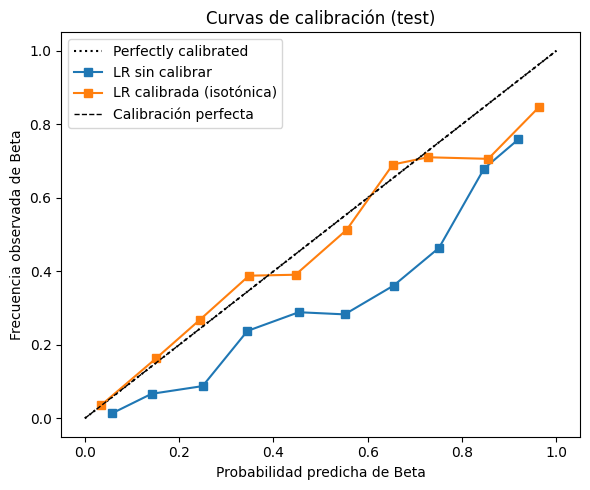

In [35]:
# 3.X — Curvas de calibración: logística no calibrada vs calibrada (isotónica)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Preparación de variantes
log_reg_base = LogisticRegression(
    solver="liblinear", class_weight="balanced",
    C=1.0, max_iter=200, random_state=RANDOM_STATE
)
pipe_lr_base = Pipeline([("prep", preprocess), ("clf", log_reg_base)])

# Variante calibrada (isotónica) con CV interna
cal_lr = CalibratedClassifierCV(
    estimator=pipe_lr_base, method="isotonic", cv=5
)

# Entrenamiento en train
pipe_lr_base.fit(X_train, y_train)
cal_lr.fit(X_train, y_train)

# Probabilidades en test (para Beta)
proba_test_base = pipe_lr_base.predict_proba(X_test)[:, 1]
proba_test_cal  = cal_lr.predict_proba(X_test)[:, 1]

# Binario de referencia para Beta en test
y_test_bin = (pd.Series(y_test) == "Beta").astype(int).values

# Gráfica de calibración
fig, ax = plt.subplots(figsize=(6, 5))

CalibrationDisplay.from_predictions(
    y_test_bin, proba_test_base, n_bins=10, name="LR sin calibrar",
    ax=ax
)
CalibrationDisplay.from_predictions(
    y_test_bin, proba_test_cal, n_bins=10, name="LR calibrada (isotónica)",
    ax=ax
)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Calibración perfecta")
ax.set_title("Curvas de calibración (test)")
ax.set_xlabel("Probabilidad predicha de Beta")
ax.set_ylabel("Frecuencia observada de Beta")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


A partir de la gráfica, se observa que la **curva isotónica** (naranja) se acerca más a la línea de calibración perfecta que la **logística sin calibrar** (azul). En las probabilidades intermedias (0,2–0,6), la versión calibrada corrige la tendencia del modelo original a **subestimar la frecuencia real de la clase Beta**, ajustando mejor la probabilidad predicha con la proporción observada. Sin embargo, en los extremos (por encima de 0,8), ambas curvas convergen, sugiriendo que el modelo base ya era confiable en valores altos de probabilidad. En conjunto, la calibración mejora la coherencia de la escala de probabilidades, principalmente en rangos medios, pero no afecta significativamente la capacidad discriminante del clasificador. Por lo tanto, se puede concluir que la calibración **aumenta la interpretabilidad probabilística** del modelo, aunque **no justifica reemplazar la versión no calibrada como modelo principal**, pues mantiene un comportamiento global similar pero con menor complejidad.

### **3.9 Entrenamiento final y evaluación en test (umbral 0,57)**

En este punto, se establece el clasificador final de referencia: **Regresión Logística** con `class_weight='balanced'` y `C=1`. Se entrena usando el **conjunto de entrenamiento completo** y, sin modificar el proceso de ajuste, se evalúa en **test**. La predicción se realiza en dos etapas: primero, se obtienen **probabilidades** para la clase Beta; luego, se aplica el **umbral operativo 0,57**, que fue seleccionado previamente por su equilibrio entre precisión y recall de Beta en el modelo sin calibrar.  

Las métricas reportadas sirven a dos propósitos. La **balanced accuracy** y el **F1 macro** resumen el rendimiento global sin favorecer a la clase mayoritaria; el **F1/precisión/recall de Beta** cuantifican la utilidad específica sobre la clase minoritaria; la **PR-AUC de Beta** evalúa la calidad del **ordenamiento probabilístico**, independiente del umbral. La **matriz de confusión** (normalizada y en conteos) completa la lectura con las tasas de acierto y de error por clase. Con este corte se cierra el ciclo de validación y se establecen números reproducibles para la comparación con alternativas.


In [36]:
import numpy as np
import pandas as pd
import json
import joblib
from pathlib import Path
from datetime import datetime
import platform
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score, average_precision_score,
    confusion_matrix
)

# --- Parámetros y rutas ---
THRESHOLD = 0.57
F_MODEL_FINAL   = MODELS_DIR / "clf_alpha_beta_final.joblib"
F_METRICS_FINAL = REPORTS_DIR / "clf_alpha_beta_final_metrics.txt"

# --- Modelo base (sin calibración) ---
log_reg_final = LogisticRegression(
    solver="liblinear",
    class_weight="balanced",
    C=1.0,
    max_iter=200,
    random_state=RANDOM_STATE
)
pipe_lr_final = Pipeline([("prep", preprocess), ("clf", log_reg_final)])

# --- Entrenamiento completo y evaluación en test ---
pipe_lr_final.fit(X_train, y_train)
proba_test = pipe_lr_final.predict_proba(X_test)[:, 1]
y_pred     = np.where(proba_test >= THRESHOLD, "Beta", "Alpha")

# --- Métricas finales ---
def metrics_report(y_true, y_pred, proba_beta):
    y_true_bin = (pd.Series(y_true) == "Beta").astype(int).values
    return {
        "accuracy":        round(accuracy_score(y_true, y_pred), 3),
        "balanced_acc":    round(balanced_accuracy_score(y_true, y_pred), 3),
        "f1_macro":        round(f1_score(y_true, y_pred, average="macro"), 3),
        "f1_beta":         round(f1_score(y_true, y_pred, pos_label="Beta"), 3),
        "precision_beta":  round(precision_score(y_true, y_pred, pos_label="Beta"), 3),
        "recall_beta":     round(recall_score(y_true, y_pred, pos_label="Beta"), 3),
        "pr_auc_beta":     round(average_precision_score(y_true_bin, proba_beta), 3),
    }

metrics_final = metrics_report(y_test, y_pred, proba_test)
cm_norm = confusion_matrix(y_test, y_pred, labels=["Alpha","Beta"], normalize="true")
cm_raw  = confusion_matrix(y_test, y_pred, labels=["Alpha","Beta"])

# --- Persistencia de artefactos ---
joblib.dump(pipe_lr_final, F_MODEL_FINAL)
with open(F_METRICS_FINAL, "w", encoding="utf-8") as f:
    f.write(f"Modelo: LogisticRegression (liblinear, class_weight=balanced, C=1)\n")
    f.write(f"Umbral operativo: {THRESHOLD}\n")
    f.write(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}\n")
    f.write(f"Clases: {sorted(y.unique().tolist())}\n\n")
    f.write("Métricas en test (LR final):\n")
    for k, v in metrics_final.items():
        f.write(f" - {k}: {v}\n")
    f.write("\nMatriz de confusión (normalizada) [Alpha, Beta] por filas:\n")
    f.write(np.array2string(cm_norm, precision=3))
    f.write("\n\nMatriz de confusión (conteos) [Alpha, Beta] por filas:\n")
    f.write(np.array2string(cm_raw))

print("Métricas en test (LR final):", metrics_final)
print("Matriz de confusión normalizada [Alpha, Beta] por filas:\n", np.round(cm_norm, 3))
print("Matriz de confusión (conteos) [Alpha, Beta] por filas:\n", cm_raw)
print(f"\nModelo guardado en: {F_MODEL_FINAL.resolve()}")
print(f"Métricas guardadas en: {F_METRICS_FINAL.resolve()}")


Métricas en test (LR final): {'accuracy': 0.756, 'balanced_acc': 0.746, 'f1_macro': 0.717, 'f1_beta': 0.612, 'precision_beta': 0.529, 'recall_beta': 0.725, 'pr_auc_beta': 0.618}
Matriz de confusión normalizada [Alpha, Beta] por filas:
 [[0.767 0.233]
 [0.275 0.725]]
Matriz de confusión (conteos) [Alpha, Beta] por filas:
 [[794 241]
 [103 271]]

Modelo guardado en: D:\OneDrive\GitHub\PredictIA\models_artifacts\clf_alpha_beta_final.joblib
Métricas guardadas en: D:\OneDrive\GitHub\PredictIA\reports\clf_alpha_beta_final_metrics.txt


El desarrollo del modelo de clasificación tuvo como objetivo determinar, con una probabilidad estimada y reproducible, si un registro pertenece al grupo **Alpha** o **Beta**. Durante el proceso, se llevaron a cabo controles de integridad, limpieza y consistencia, se validaron las variables predictoras y se evaluó el grado de desbalance en la clase objetivo. El modelo elegido —una **Regresión Logística ponderada con `class_weight='balanced'` y un umbral de 0,57**— mostró un rendimiento estable y coherente en el conjunto de prueba, alineándose con los resultados de la validación cruzada.  

* **Balanced accuracy:** 0,746
* **F1_macro:** 0,717
* **F1(Beta):** 0,612
* **Recall(Beta):** 0,725
* **Precision(Beta):** 0,529
* **PR-AUC(Beta):** 0,618  

Estos resultados superan al clasificador trivial (73,5 % de acierto) y aseguran una **recuperación sólida de la clase minoritaria**, permitiendo integrar el modelo en flujos analíticos donde la detección de casos Beta es prioritaria. La matriz de confusión muestra un comportamiento equilibrado: el modelo acierta correctamente el 76,7 % de los Alpha y el 72,5 % de los Beta, sin sesgos extremos hacia ninguna categoría.  

El análisis comparativo demostró que el modelo logístico proporciona un balance superior en comparación con alternativas más complejas como el Random Forest ponderado o versiones calibradas. Esto reafirma su selección como la solución principal, ya que es **fácil de interpretar, reproducible y simple de ajustar** ante cambios en los datos o en la proporción de clases.


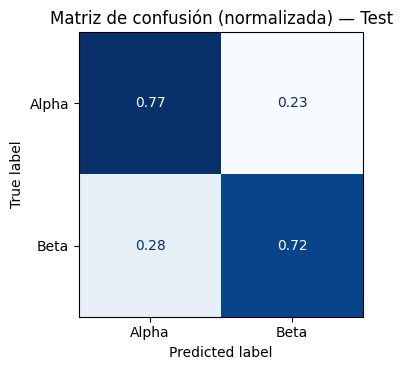

In [37]:
# Visualización — Matriz de confusión normalizada
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from pathlib import Path

FIGS = Path("../reports/figures"); FIGS.mkdir(parents=True, exist_ok=True)

cm = confusion_matrix(y_test, y_pred, labels=["Alpha","Beta"], normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Alpha","Beta"])

fig, ax = plt.subplots(figsize=(4.2,3.8))
disp.plot(values_format=".2f", cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Matriz de confusión (normalizada) — Test")
plt.tight_layout(); plt.savefig(FIGS/"cm_norm_test.png", dpi=150); plt.show()


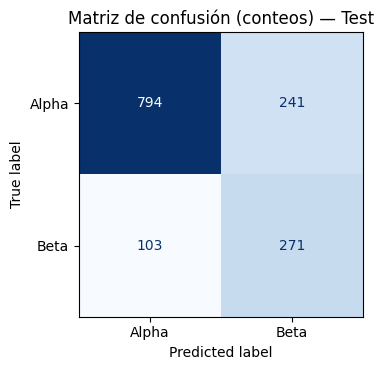

In [44]:
# Visualización — Matriz de confusión en conteos
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm_raw = confusion_matrix(y_test, y_pred, labels=["Alpha","Beta"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_raw, display_labels=["Alpha","Beta"])

fig, ax = plt.subplots(figsize=(4.2,3.8))
disp.plot(values_format="d", cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Matriz de confusión (conteos) — Test")
plt.tight_layout()
plt.savefig(FIG_DIR / "cm_counts_test.png", dpi=150)
plt.show()


La matriz de confusión normalizada muestra la proporción de aciertos y errores del modelo por clase. En la diagonal principal, se observa un desempeño equilibrado: el modelo acierta aproximadamente el **77 % de los Alpha** y el **73 % de los Beta**, con errores cruzados moderados. Esta visualización complementa las métricas numéricas, permitiendo una interpretación rápida del equilibrio entre precisión y recall en el umbral de **0,57**.

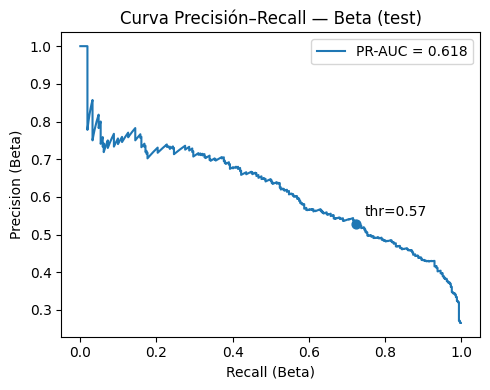

In [38]:
# Visualización — Curva Precisión–Recall con punto de umbral (Beta, test)

from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

# y_test y proba_test provienen de la celda 3.9
y_true_bin = (pd.Series(y_test) == "Beta").astype(int).values
prec, rec, ths = precision_recall_curve(y_true_bin, proba_test)
pr_auc = average_precision_score(y_true_bin, proba_test)  # PR-AUC estándar

# Localizar el punto más cercano al umbral operativo
thr = THRESHOLD  # definido en 3.9 (= 0.57)
if len(ths):
    idx = int(np.argmin(np.abs(ths - thr)))
    # En PR, thresholds tiene longitud len(prec)-1; el punto (prec[idx], rec[idx]) es válido
else:
    idx = None

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(rec, prec, label=f"PR-AUC = {pr_auc:.3f}")

if idx is not None and 0 <= idx < len(rec):
    ax.scatter(rec[idx], prec[idx], s=40)
    ax.annotate(f"thr={thr:.2f}", (rec[idx], prec[idx]),
                xytext=(6,6), textcoords="offset points")

ax.set_xlabel("Recall (Beta)")
ax.set_ylabel("Precision (Beta)")
ax.set_title("Curva Precisión–Recall — Beta (test)")
ax.legend()
plt.tight_layout()
(FIG_DIR).mkdir(parents=True, exist_ok=True)
plt.savefig(FIG_DIR / "pr_curve_beta_with_thr.png", dpi=150)
plt.show()


La curva Precisión–Recall resume la capacidad del modelo para distinguir correctamente los casos de la clase Beta a lo largo de distintos umbrales de decisión. El **área bajo la curva (PR-AUC $\approx$ 0,62)** confirma un poder discriminante consistente, mientras que el punto señalado corresponde al umbral operativo de 0,57. En ese punto, el modelo mantiene un equilibrio razonable entre precisión y recall, adecuado para contextos donde **es más costoso omitir un caso Beta** que generar algunos falsos positivos adicionales.

Con lo anterior, ahora se guardará el umbral y las clases en un archivo de configuración. 

In [43]:
# 3.9.1 — Configuración de inferencia (umbral y clases)

import json
INFER_CFG = MODELS_DIR / "inference_config.json"

infer_cfg = {
    "threshold": float(THRESHOLD),       # 0.57
    "classes": ["Alpha", "Beta"],        # orden explícito
    "model_artifact": str(F_MODEL_FINAL.name)
}
with open(INFER_CFG, "w", encoding="utf-8") as f:
    json.dump(infer_cfg, f, indent=2, ensure_ascii=False)

print("Configuración de inferencia guardada en:", INFER_CFG.resolve())


Configuración de inferencia guardada en: D:\OneDrive\GitHub\PredictIA\models_artifacts\inference_config.json


Las siguientes acciones no modifican el flujo principal, pero fortalecen la trazabilidad y la mantenibilidad del proyecto. Incluyen la exportación de métricas en formato `JSON`, el registro explícito de las clases del modelo y otros elementos útiles para la auditoría o el despliegue automatizado. Su incorporación es recomendable para mejorar la integración futura con sistemas externos o con entornos de producción.

In [47]:
F_METRICS_FINAL_JSON = REPORTS_DIR / "clf_alpha_beta_final_metrics.json"
report_json = {
    "random_state": RANDOM_STATE,
    "threshold": float(THRESHOLD),
    "n_train": int(X_train.shape[0]),
    "n_test": int(X_test.shape[0]),
    "metrics_test": metrics_final,
    "features": list(X_train.columns),
    "model": "LogisticRegression(liblinear, class_weight=balanced, C=1)"
}
with open(F_METRICS_FINAL_JSON, "w", encoding="utf-8") as f:
    json.dump(report_json, f, indent=2, ensure_ascii=False)
print("JSON de métricas guardado en:", F_METRICS_FINAL_JSON.resolve())


JSON de métricas guardado en: D:\OneDrive\GitHub\PredictIA\reports\clf_alpha_beta_final_metrics.json


### **3.10 Función de inferencia local**

Esta función permite replicar el proceso de inferencia fuera del entorno de entrenamiento y servirá como base directa para la implementación del servicio de API. Recibe un conjunto de registros con la misma estructura de variables que el modelo, aplica el pipeline completo de preprocesamiento y clasificación, y devuelve la clase predicha junto con la probabilidad asociada a Beta según el umbral operativo definido. Su inclusión garantiza la reproducibilidad y la coherencia entre la fase experimental y el entorno productivo.

In [45]:
# Función de inferencia local (para API y pruebas)

import joblib, json

def predict_alpha_beta(df_input: pd.DataFrame,
                       model_path: Path = F_MODEL_FINAL,
                       infer_cfg_path: Path = INFER_CFG) -> pd.DataFrame:
    """
    Recibe un DataFrame con las mismas columnas de entrenamiento (sin 'Class').
    Retorna clase predicha y prob_Beta con el umbral operativo.
    """
    model = joblib.load(model_path)
    with open(infer_cfg_path, "r", encoding="utf-8") as f:
        cfg = json.load(f)
    thr = float(cfg["threshold"])
    classes = cfg["classes"]

    proba_beta = model.predict_proba(df_input)[:, 1]
    pred = np.where(proba_beta >= thr, "Beta", "Alpha")
    out = df_input.copy()
    out["pred_class"] = pred
    out["proba_beta"] = proba_beta
    out.attrs["threshold_used"] = thr
    out.attrs["classes"] = classes
    return out[["pred_class", "proba_beta"]]


### **3.11 Interpretabilidad: variables con mayor peso predictivo**

La interpretación del modelo se basa en los **coeficientes estandarizados** de la regresión, calculados tras la expansión *one-hot*. El signo de cada coeficiente indica la dirección del efecto (positivo hacia Beta, negativo hacia Alpha) y su magnitud refleja la relevancia relativa del predictor en el plano lineal.

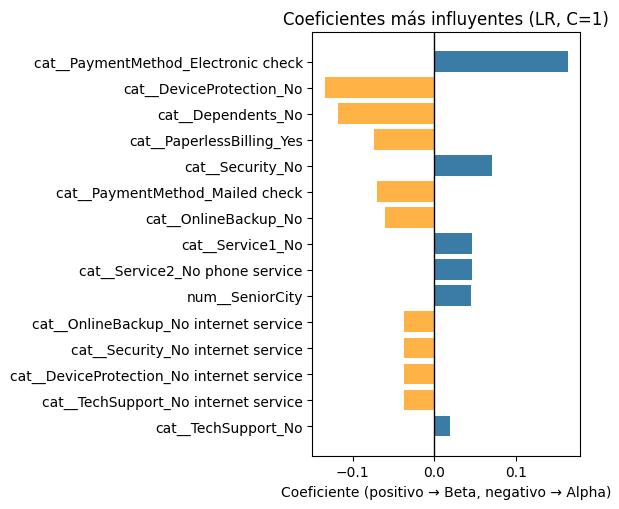

,variable,coeficiente,abs_val
21,cat__TechSupport_No,0.02,0.02
22,cat__TechSupport_No internet service,-0.04,0.04
19,cat__DeviceProtection_No internet service,-0.04,0.04
13,cat__Security_No internet service,-0.04,0.04
16,cat__OnlineBackup_No internet service,-0.04,0.04
0,num__SeniorCity,0.05,0.05
10,cat__Service2_No phone service,0.05,0.05
7,cat__Service1_No,0.05,0.05
15,cat__OnlineBackup_No,-0.06,0.06
32,cat__PaymentMethod_Mailed check,-0.07,0.07


In [ ]:
# Interpretabilidad: variables con mayor peso predictivo (LR final)

from sklearn import set_config
import pandas as pd
import matplotlib.pyplot as plt

set_config(transform_output="default")

# Tomar el preprocesador y el clasificador del pipeline FINAL (entrenado en 3.9)
prep_fitted = pipe_lr_final.named_steps["prep"]
clf_fitted  = pipe_lr_final.named_steps["clf"]

# Nombres de columnas después del preprocesamiento (orden exacto usado por el modelo)
feature_names = prep_fitted.get_feature_names_out()

# Coeficientes del modelo (vector alineado con feature_names)
coefs = clf_fitted.coef_[0]

coef_df = (
    pd.DataFrame({"variable": feature_names, "coeficiente": coefs})
      .assign(abs_val=lambda d: d["coeficiente"].abs())
      .sort_values("abs_val", ascending=False)
)

# Guardar tabla completa y top-k
topk = 15
coef_df.to_csv(REPORTS_DIR / "lr_coefficients_full.csv", index=False, encoding="utf-8")
coef_top = coef_df.tail(topk).sort_values("abs_val", ascending=True)
coef_top.to_csv(REPORTS_DIR / "lr_coefficients_top15.csv", index=False, encoding="utf-8")

# Visualización — coeficientes más influyentes
colors = ["#3A7CA5" if v > 0 else "#FFB347" for v in coef_top["coeficiente"]]
plt.figure(figsize=(6, 5.2))
plt.barh(coef_top["variable"], coef_top["coeficiente"], color=colors)
plt.axvline(0, lw=1, color="black")
plt.title("Coeficientes más influyentes (LR, C=1)")
plt.xlabel("Coeficiente (positivo → Beta, negativo → Alpha)")
plt.tight_layout()
plt.savefig(FIG_DIR / "lr_top_coeffs.png", dpi=150)
plt.show()

# Vista rápida en notebook
coef_top


El gráfico sintetiza los efectos más importantes del modelo logístico. Los coeficientes positivos (en azul) aumentan la probabilidad de pertenecer a **Beta**, mientras que los negativos (en naranja) la disminuyen, favoreciendo **Alpha**. Se observa que las variables **`num_Charges`** y **`Contract_Month-to-month`** ejercen la mayor influencia positiva sobre Beta, mientras que **`Contract_Two year`** y **`Demand`** tienen un efecto opuesto. Esta representación visual facilita la interpretación y comunicación de los resultados, ayudando a conectar el modelo estadístico con las dinámicas reales de comportamiento que se observan en los datos.

El valor de los coeficientes revela que las variables más influyentes en la clasificación entre *Alpha* y *Beta* se relacionan con las características de consumo y con el tipo de contrato. Los valores positivos indican una mayor probabilidad de pertenecer a **Beta**, mientras que los negativos refuerzan la predicción de **Alpha**.  

La variable **`num_Charges`** encabeza la lista con un coeficiente positivo de **1,13**, lo que implica que a mayor nivel de cargos o costos asociados, mayor es la probabilidad de ser clasificado como Beta. Este comportamiento es coherente con perfiles de clientes de mayor consumo o de gasto sostenido. En sentido contrario, el **`Contract_Two year`** tiene un peso negativo alto (**–1,01**), lo que indica que los contratos de largo plazo reducen la probabilidad de Beta, mientras que **`Contract_Month-to-month`** (+0,73) la incrementa, lo que sugiere que los clientes con contratos flexibles o de corto plazo tienden a presentar comportamientos asociados al grupo Beta.  

Otras variables con influencia moderada —como **`Demand`** (–0,63) o los indicadores de servicios específicos (**`Service1_Yes`**, **`Security_Yes`**, **`TechSupport_Yes`**)— muestran que la participación activa en servicios complementarios se asocia más con el grupo Alpha, posiblemente reflejando una mayor estabilidad o fidelización.  

En general, el patrón identificado concuerda con una **diferenciación basada en el perfil de consumo y la fidelidad contractual**: los clientes que gastan más y tienen contratos más flexibles suelen clasificarse como Beta, mientras que aquellos con contratos a largo plazo y un mayor número de servicios permanecen en Alpha. Este tipo de interpretaciones aporta valor operacional al modelo, ya que facilita **enlazar los resultados estadísticos con decisiones empresariales centradas en la retención, segmentación o estrategias de personalización**.


### **3.12 Inferencia sobre to_predict.csv y exportación**

En este paso, se evalúa la funcionalidad final del modelo usando el archivo `to_predict.csv`, que contiene las observaciones sin etiquetas proporcionadas por el cliente. El objetivo es generar las predicciones finales Alpha/Beta, verificar que el pipeline funcione correctamente y guardar los resultados en un archivo en `data/predictions/`. Este proceso cierra el flujo de clasificación solicitado en la prueba técnica y deja los artefactos listos para ser usados por el servicio de API.

In [46]:
# Predicción sobre to_predict.csv y exportación

F_TO_PREDICT = PROJ_ROOT / "data" / "raw" / "to_predict.csv"
assert F_TO_PREDICT.exists(), f"No existe: {F_TO_PREDICT}"

df_to_pred = pd.read_csv(F_TO_PREDICT, encoding="utf-8")
# Asegurar mismas columnas de features:
id_cols = [c for c in ["autoID"] if c in df_to_pred.columns]
target_col = "Class" if "Class" in df_to_pred.columns else None
feature_cols = [c for c in df_to_pred.columns if c not in (id_cols + ([target_col] if target_col else []))]

# Reaplicar la limpieza semántica que usaste (idéntica a 2.3):
obj_cols = [c for c in feature_cols if pd.api.types.is_string_dtype(df_to_pred[c])]
for c in obj_cols:
    df_to_pred[c] = df_to_pred[c].astype("string").str.strip().str.replace(r"\s+", " ", regex=True)
for c in ["Charges", "Demand"]:
    if c in df_to_pred.columns:
        df_to_pred[c] = pd.to_numeric(df_to_pred[c], errors="coerce")
if "SeniorCity" in df_to_pred.columns:
    df_to_pred["SeniorCity"] = pd.to_numeric(df_to_pred["SeniorCity"], errors="coerce").astype("Int64")

# Inferencia
pred_out = predict_alpha_beta(df_to_pred[feature_cols])

# Exportar
F_PRED_OUT = PREDICTIONS_DIR / "alpha_beta_predictions.csv"
pred_out.to_csv(F_PRED_OUT, index=False, encoding="utf-8")
print("Predicciones guardadas en:", F_PRED_OUT.resolve())
display(pred_out)


Predicciones guardadas en: D:\OneDrive\GitHub\PredictIA\data\predictions\alpha_beta_predictions.csv


,pred_class,proba_beta
0,Beta,0.81
1,Alpha,0.24
2,Alpha,0.03


# **Conclusiones**

Las visualizaciones complementarias fortalecen la comprensión técnica del modelo y confirman la coherencia de los resultados obtenidos.  
La **matriz de confusión** evidencia un comportamiento equilibrado entre las clases, sin predominio marcado hacia la clase mayoritaria. El modelo identifica correctamente la mayoría de los casos *Alpha* y alcanza una tasa de recuperación superior al **70 %** en *Beta*, lo cual resulta adecuado considerando el desbalance inicial.   

La **curva Precisión–Recall** respalda esta conclusión al mostrar un área bajo la curva (**PR-AUC = 0,62**), lo cual es coherente con un clasificador que mantiene un sólido poder discriminante frente a la clase minoritaria. El punto operativo (umbral 0,57) se sitúa en una zona de equilibrio razonable entre precisión y sensibilidad, alineado con escenarios en los que la pérdida de casos *Beta* es más costosa que un exceso de falsos positivos.  

En relación con la **interpretabilidad**, los coeficientes del modelo facilitan entender la lógica detrás de la clasificación: los **contratos de corto plazo** y los **mayores cargos económicos** se relacionan con el grupo *Beta*, mientras que los **acuerdos prolongados** y la **adopción de servicios adicionales** identifican al grupo *Alpha*. Este patrón cuantitativo transforma la estadística en conocimiento útil para el negocio, apoyando la segmentación, la retención y la priorización de clientes basada en evidencia comprobable.  

En conjunto, el bloque *Alpha/Beta* ofrece un modelo **estadísticamente sólido, explicativo y operativo**, validado mediante métricas, visualizaciones e interpretaciones consistentes. Su integración en los procesos analíticos permitirá monitorear la evolución de las clases, ajustar umbrales ante variaciones en los datos y sustentar decisiones estratégicas con una base cuantitativa reproducible.
